In [12]:
import os
import sys

# Add project root (the folder that contains 'src') to sys.path so `from src...` works when
# running notebooks from the notebooks/ subfolder.

def find_project_root(start=os.getcwd()):
    cur = os.path.abspath(start)
    while True:
        if os.path.isdir(os.path.join(cur, "src")):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            raise FileNotFoundError("Could not find project root containing 'src'")
        cur = parent

proj_root = find_project_root()
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)
print("Added to sys.path:", proj_root)


Added to sys.path: c:\Users\Krishnendu Manna\Documents\new steup\Traffic-clusturing\city-traffic-clustering


In [6]:
from src.traffic_environment import TrafficEnvironment
import numpy as np
import matplotlib.pyplot as plt


In [8]:
import os
import pandas as pd

# Load scenarios and traffic data used by TrafficEnvironment
# These files live under data/processed by default in this project.
scenarios_path = os.path.join(proj_root, "data", "processed", "traffic_scenarios_from_clusters_k4.csv")
traffic_data_path = os.path.join(proj_root, "data", "processed", "bangalore_traffic_processed.csv")

missing = []
if not os.path.exists(scenarios_path):
    missing.append(scenarios_path)
if not os.path.exists(traffic_data_path):
    missing.append(traffic_data_path)

if missing:
    raise FileNotFoundError(
        "Required data files not found. Expected:\n  "
        + "\n  ".join(missing)
        + "\nPlease ensure these files exist under data/processed or update the paths."
    )

scenarios = pd.read_csv(scenarios_path)
traffic_data = pd.read_csv(traffic_data_path)

print("Loaded scenarios:", scenarios_path, "->", scenarios.shape)
print("Loaded traffic_data:", traffic_data_path, "->", traffic_data.shape)
print("scenario columns:", scenarios.columns.tolist())
print("traffic_data columns:", traffic_data.columns.tolist())

# Ensure required columns exist (attempt common renames if necessary)
required = {"spawn_rate", "Average Speed"}
found = set(scenarios.columns)
missing_cols = required - found
if missing_cols:
    # try common alternatives
    if "avg_speed" in scenarios.columns and "Average Speed" not in scenarios.columns:
        scenarios = scenarios.rename(columns={"avg_speed": "Average Speed"})
    if "spawnRate" in scenarios.columns and "spawn_rate" not in scenarios.columns:
        scenarios = scenarios.rename(columns={"spawnRate": "spawn_rate"})
    found = set(scenarios.columns)
    missing_cols = required - found
    if missing_cols:
        raise KeyError(
            f"Scenarios file is missing required columns {missing_cols}. Found columns: {scenarios.columns.tolist()}"
        )

print("Scenarios columns OK. Proceeding.")


Loaded scenarios: c:\Users\Krishnendu Manna\Documents\new steup\Traffic-clusturing\city-traffic-clustering\data\processed\traffic_scenarios_from_clusters_k4.csv -> (4, 12)
Loaded traffic_data: c:\Users\Krishnendu Manna\Documents\new steup\Traffic-clusturing\city-traffic-clustering\data\processed\bangalore_traffic_processed.csv -> (8936, 14)
scenario columns: ['cluster_id', 'traffic_state_name', 'Traffic Volume', 'Average Speed', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'spawn_rate', 'sim_speed', 'incident_prob', 'count', 'share_%']
traffic_data columns: ['Traffic Volume', 'Average Speed', 'Travel Time Index', 'Congestion Level', 'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact', 'Pedestrian and Cyclist Count', 'IsWeekend', 'Weather Conditions_Fog', 'Weather Conditions_Overcast', 'Weather Conditions_Rain', 'Weather Conditions_Windy', 'Roadwork and Construction Activity_Yes']
Scenarios columns OK. Proceeding.


In [9]:
env = TrafficEnvironment(scenarios, traffic_data)
env.reset()


{'cluster': 0,
 'queue_ns': 0,
 'queue_ew': 0,
 'signal_state': 'green-ns',
 'avg_speed': 50.0}

In [10]:
wait, queue = [], []
for _ in range(500):
    _,_,_,info = env.step(np.random.randint(5))
    wait.append(info["avg_wait_time"])
    queue.append(info["total_queue"])


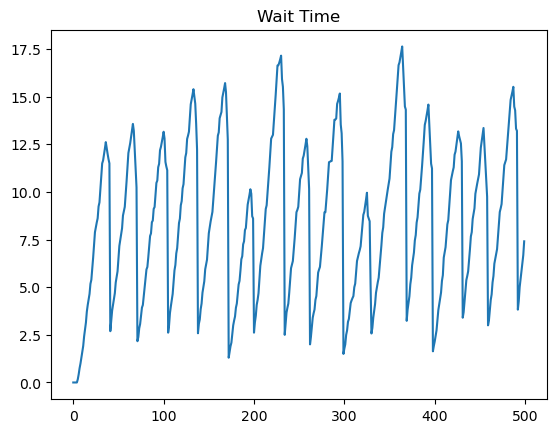

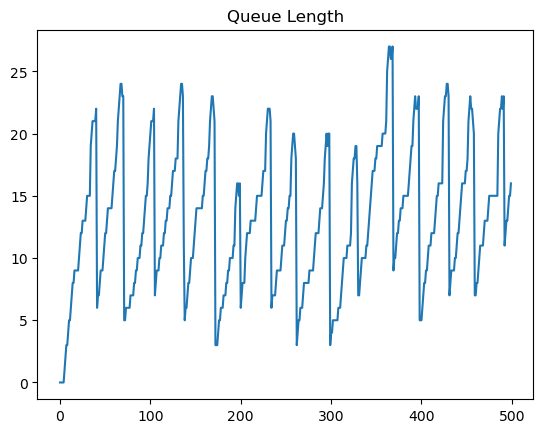

In [11]:
plt.plot(wait); plt.title("Wait Time"); plt.show()
plt.plot(queue); plt.title("Queue Length"); plt.show()